# TP4 - Auto-encoder

## Un auto-encodeur sur MNIST
Implémenter un auto-encoder pour débruiter des données de types MNIST, dont l'architecture sera celle proposée dans le cours.

Les données d'entrée devront être normalisées puis bruitées à l'aide de la fonction `add_noise()` fournie dans la première cellule de code. L'apprentissage se fera sur 12 itérations avec des batchs de taille 128 et en utilisant la méthode de gradient Adam avec les paramètres par défaut.

Afficher un graphique montrant l'évolution du coût, calculés sur les ensembles d'apprentissage et de tests, au fur-et-à-mesure des itérations.

Attention le code de bruitage utilise une fonction issue du package `scikit-image` nécessitant une installation dans l'environnement de travail :

> `pip install scikit-image`

### Architecture
La partie encodeur pourra avoir la structure séquentiellement suivante : 
- Couche `Conv2D` : 16 filtres (3x3), strides (2x2), zero-padding, ReLU
- Couche `Conv2D` : 32 filtres (3x3), strides (2x2), zero-padding, ReLU
- Couche `Dense` : 16 neurones, ReLU
- Couche `Dense` vers l'espace latent sans activation

La partie decodeur prendra en entrée des données issues de l'espace latent et aura une structure en "miroir" par rapport à l'encodeur. Quelques méthodes sur Keras pour implémenter cette partie : 
- Pour "inverser" une couche de convolution : `Conv2DTranspose`
- Pour "inverser" une couche d'applatissement (`Flatten`) : utiliser `Reshape`
- Utiliser la fonction d'activation sigmoïde en sortie afin de retrouver des valeurs dans [0, 1].

Le modèle global d'auto-encodeur combinera les deux parties en utilisation un espace latent de taille 10 et une fonction de coût `"binary_crossentropy"`


### A propos de l'API fonctionnelle de Keras
Keras propose différentes manières de créer un objet de type Model.

Pour un modèle avec une seule entrée, une seule sortie et un empilement simple de couches, la classe Sequential peut être utilisée :
```
model = keras.Sequential()
model.add(keras.layers.Input((28,28,1)))
model.add(keras.layers.Conv2D(filters=6, kernel_size=5, padding="same", activation="relu"))
model.add(keras.layers.MaxPooling2D((2,2)))
model.add(keras.layers.Dense(10,activation="softmax"))

model.compile(...)
```

Pour des modèles plus complexes (comportant des morceaux recombinés ou différentes formes d'entrées ou de sorties), il peut être nécessaire d'utiliser l'API fonctionnelle de Keras. Le principe consiste à construire un modèle couche par couche en connectant des entrées et des sorties. La modèle est finalement construite par la classe générique `Model()` en précisant les entrée et sorties globales.

```
inputs = keras.Input(shape=(28,28,1))
x = keras.layers.Conv2D(filters=6, kernel_size=3, padding='same', activation='relu')(inputs)
x = keras.layers.MaxPooling2D((2,2))(x)
outputs = keras.layers.Dense(10,activation="softmax") (x)

model = keras.Model(inputs, outputs, name="mon modèle")
model.compile(...)
```

L'API fonctionnelle permet d'utiliser les couches et les modèles comme des fonctions s'appliquant sur des entrées. Une fois un modèle créé, il peut être utilisé comme élément d'un autre modèle comme s'il s'agissait d'une simple couche.




In [1]:
# Imports et initialisations pour les exercices 1 et 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras

from skimage.util import random_noise

from pathlib import Path

# Création d'un dossier "models" où stocker les modèles
MODEL_FOLDER ="models"
Path(MODEL_FOLDER).mkdir(parents=True, exist_ok=True)


def show_data_img(X, max_img=200, max_line=10, max_per_line=20, dpi=100):
    shape = X.shape[1:]
    nb = min(X.shape[0], max_img)
    if nb%max_per_line==0: nl = nb // max_per_line
    else: nl = nb // max_per_line + 1
    hs = shape[0]*max_per_line/dpi *1.5
    vs = shape[1]*nl/dpi *1.5
    plt.figure(figsize=(hs, vs), dpi=dpi) #(7.195, 3.841)
    for i in range(nb):
        plt.subplot(nl,max_per_line,i+1)
        plt.imshow(X[i,:].reshape(shape), cmap='gray')
        plt.axis('off')
    plt.plot()


def add_noise(data):
    new_data = np.copy(data)
    for i, image in enumerate(new_data):
        image = random_noise(image, mode='gaussian', mean=0, var=0.3)
        image = random_noise(image, mode='s&p', amount=0.2, salt_vs_pepper=0.5)
        image = random_noise(image, mode='poisson')
        image = random_noise(image, mode='speckle', mean=0, var=0.1)
        new_data[i] = image
    print('Done')
    return new_data

def plot_metrics(accuracy, loss):
    models = list(dict.fromkeys(
        k.replace('_train', '').replace('_test', '') 
        for k in accuracy.keys()
    ))
    
    palette = plt.cm.tab10.colors
    color_map = {model: palette[i % len(palette)] for i, model in enumerate(models)}
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    for key, values in accuracy.items():
        is_train = '_train' in key
        model = key.replace('_train', '').replace('_test', '')
        ax1.plot(values,
                 label=key,
                 color=color_map[model],
                 linewidth=2 if is_train else 1.2,
                 linestyle='-' if is_train else '--')
    ax1.set_title("Evolution de l'accuracy au cours de l'entrainement")
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    for key, values in loss.items():
        is_train = '_train' in key
        model = key.replace('_train', '').replace('_test', '')
        ax2.plot(values,
                 label=key,
                 color=color_map[model],
                 linewidth=2 if is_train else 1.2,
                 linestyle='-' if is_train else '--')
    ax2.set_title("Evolution de la loss au cours de l'entrainement")
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()




Done
Done


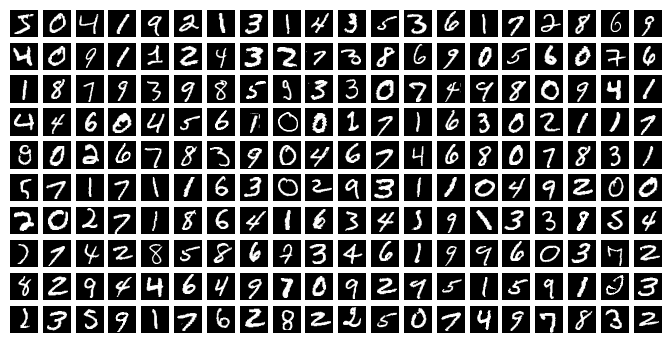

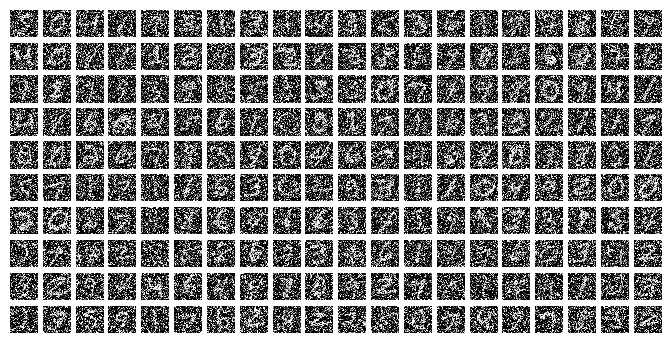

In [ ]:
from keras import layers
from keras.datasets import mnist
(X_train, _), (X_val, _) = mnist.load_data()

# - On normalise en divisant par 255 (valeur maximale d'un pixel)
X_train = X_train / 255
X_val = X_val / 255

# Afficher les données chargé
show_data_img(X_train)

noisy_X_train = add_noise(X_train)
noisy_X_val = add_noise(X_val)

# Afficher les données bruités
show_data_img(noisy_X_train)

acc = {}
loss = {}

La partie encodeur pourra avoir la structure séquentiellement suivante : 
- Couche `Conv2D` : 16 filtres (3x3), strides (2x2), zero-padding, ReLU
- Couche `Conv2D` : 32 filtres (3x3), strides (2x2), zero-padding, ReLU
- Couche `Dense` : 16 neurones, ReLU
- Couche `Dense` vers l'espace latent sans activation

In [6]:
X_train.shape

(60000, 28, 28)

In [12]:
latent_size = 10
# Modèle encodeur 
inputs = keras.layers.Input(shape=(28,28,1))
x = layers.Conv2D(16,kernel_size=(3,3), strides=(2,2),padding="same",activation='relu') (inputs)
x = layers.Conv2D(32,kernel_size=(3,3), strides=(2,2),padding="same",activation='relu') (x)
x = keras.layers.Flatten()(x)
x = layers.Dense(16,activation='relu')(x)
outputs = keras.layers.Dense(latent_size)(x)
encodeur = keras.Model(inputs,outputs,name="Encodeur")

encodeur.summary()
# Modèle décodeur
inputs = keras.layers.Input(shape=(latent_size,))
x = keras.layers.Dense(7*7*32,activation='relu')(inputs)
x = keras.layers.Reshape((7,7,32))(x)
x = keras.layers.Conv2DTranspose(32,kernel_size=(3,3), strides=(2,2),padding="same",activation='relu') (x)
x = keras.layers.Conv2DTranspose(32,kernel_size=(3,3), strides=(2,2),padding="same",activation='relu') (x)
outputs = keras.layers.Conv2DTranspose(1,kernel_size=(3,3),padding='same',activation='sigmoid')(x)
decodeur = keras.Model(inputs,outputs,name="Decodeur")

# AE
inputs = keras.layers.Input(shape=(28,28,1))
latents = encodeur(inputs)
outputs = decodeur(latents)

ae = keras.Model(inputs,outputs,name='AE')
ae.compile(optimizer='adam',loss='binary_crossentropy')



Model: "Encodeur"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │        25,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,074 (117.48 KB)

 Trainable params: 30,074 (117.48 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
batch_size = 128
nb_epoch = 20

s = ae.fit(noisy_X_train, X_train, batch_size=batch_size, epochs=nb_epoch, verbose=1, validation_data=(noisy_X_val, X_val))

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - loss: 0.2766 - val_loss: 0.2390
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.2030 - val_loss: 0.1818
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.1776 - val_loss: 0.1725
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.1699 - val_loss: 0.1655
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.1648 - val_loss: 0.1621
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.1614 - val_loss: 0.1588
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.1587 - val_loss: 0.1573
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.1565 - val_loss: 0.1550
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.1550 - val_loss: 0.1536
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.1538 - val_loss: 0.1533
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.1528 - val_loss: 0.1525
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━

<Axes: >

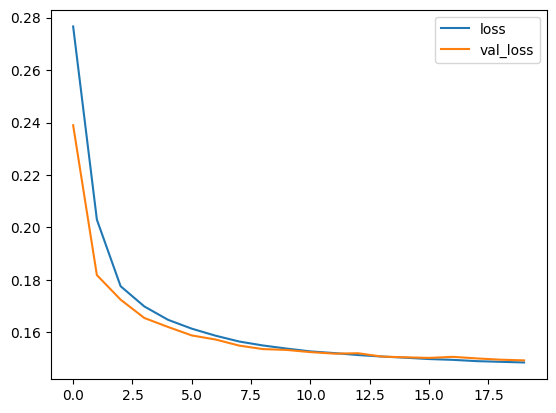

In [14]:
pd.DataFrame(s.history).plot()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


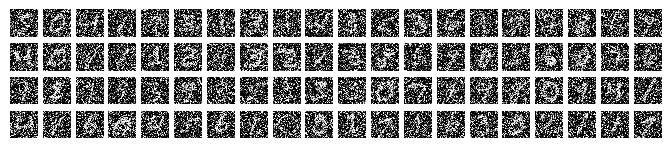

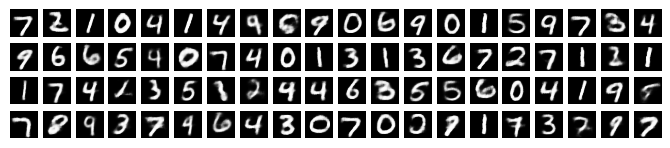

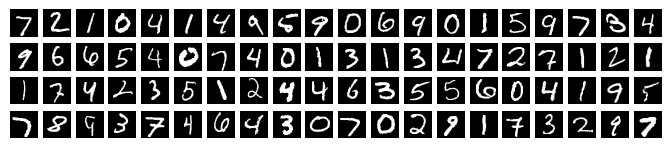

In [16]:
pred = ae.predict(X_val)

show_data_img(noisy_X_train,max_img=80)
show_data_img(pred,max_img=80)
show_data_img(X_val,max_img=80)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


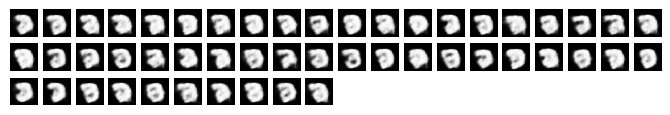

In [ ]:
alea = np.random.rand(50,10)
pred = decodeur.predict(alea)
show_data_img(pred)